# 09 · Evaluating the retrieval system

The previous notebooks built a system with several interchangeable parts, a chunk strategy, an
embedding model, a retrieval mode and a reranker, and two ways of answering. This notebook explains
how those choices were evaluated and reports which configuration was selected.

The evaluation code is `ocular/rag/eval_rag.py` and the question set is produced by
`ocular/rag/questions.py`. The sweeps were run by `experiments/run_rag_eval.py` (the retrieval
configurations) and `experiments/run_phaseb.py` (basic against agentic), which wrote their results
to the two CSV files this notebook reads.

## Reference-free evaluation

The system is scored without any hand-written answers or relevance labels, using a language model
as the judge. Three metrics are computed, the standard reference-free set.

**Faithfulness** asks whether every claim in the answer is supported by the retrieved passages,
which is the check for invented content and matters most for a clinical tool. **Answer relevance**
asks whether the answer addresses the question. **Context precision** asks what fraction of the
retrieved passages are relevant to the question, and it stands in for the labelled retrieval
metrics that a manual gold set would provide.

This approach avoids the labour of building a gold set, but two honest limitations follow. The
judge is the sole authority, so its biases become the reported numbers, and a faithful answer built
on wrongly retrieved passages can still be factually wrong, because faithfulness measures grounding
rather than correctness.

## The synthetic question set

The evaluation still needs questions, which are generated from the corpus itself. A passage is
sampled from an article and the language model is asked to write a realistic clinical question that
the passage answers. Several safeguards protect the quality of the set. The model is instructed to
paraphrase rather than copy the passage, so the questions are not trivially retrievable by matching
words. It also gates each passage on scope before writing anything, keeping only those that support a
targeted clinical question about an ocular or visual condition, and rejecting a passage that is a
study's specific results or statistics, animal or molecular bench research, engineering or
administrative detail, or a systemic topic that is not itself about the eye. This gate rejects roughly
three passages in four, so the set fills with clinically substantive, on-scope questions rather than
with corpus trivia. Fifty questions were produced in this way, each drawn from a different article.

In [1]:
from ocular.rag import questions

qs = questions.load_questions()
print(f"{len(qs)} evaluation questions\n")
for q in qs[:3]:
    print("-", q.question)

50 evaluation questions

- What clinical presentation of thyroid eye disease is notably common in non-white patient populations?
- What is the role of intracameral antibiotics in the prevention of postoperative endophthalmitis following ocular surgery?
- What key molecular drivers and signaling pathways contribute to retinal pigment epithelium (RPE) fibrosis and epithelial-mesenchymal transition?


## Phase A, choosing the retrieval configuration

The first sweep isolates each of the four retrieval choices in turn. It starts from one baseline
configuration, namely fixed chunks embedded with the biomedical model, retrieved in hybrid mode and
reranked with the gte-modernbert model, and then varies a single choice at a time while the others
are held fixed, so the effect of that choice can be read on its own rather than tangled with the
others.

A first observation shapes everything that follows. Faithfulness and answer relevance sit at or near
their maximum for every configuration, so the grounding is robust but these two metrics do not
separate the configurations. Context precision is therefore the metric that carries the signal, and
it is the one reported below.

In [2]:
import pandas as pd

from ocular import config

RESULTS = config.ROOT / "experiments" / "results"
a = pd.read_csv(RESULTS / "rag_eval.csv")
a[["faithfulness", "answer_relevance", "context_precision"]].agg(["mean", "min", "max"]).round(3)

,faithfulness,answer_relevance,context_precision
mean,1.0,0.997,0.758
min,1.0,0.990,0.644
max,1.0,1.000,0.826


### The reranker is the most influential choice

Holding the chunk strategy, the embedding model and the retrieval mode fixed and changing only the
reranker moves context precision more than any other single choice. Adding the gte-modernbert
reranker raises it from 0.76 without reranking to 0.83, a gain of about seven points. The lighter
ms-marco reranker does not help at all and is marginally worse than no reranking, at 0.74. The lesson
is that the reranker is the decisive component and that a weak reranker is worse than none, so the
choice of reranker matters more than the mere decision to use one. A far heavier reranker was also
tried in earlier work and discarded, because it improved the score by only about one point while
making each query around twenty seconds slower.

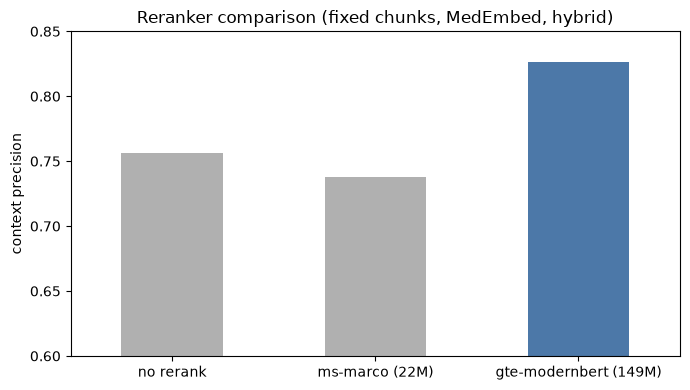

In [3]:
import matplotlib.pyplot as plt

# the reranker axis: no rerank vs the two rerankers, all else held at the baseline
rr = a[(a["chunk_strategy"] == "fixed")
       & (a["embed_model"] == "MedEmbed-base-v0.1")
       & (a["mode"] == "hybrid")].copy()
label = {
    "none": "no rerank",
    "ms-marco-MiniLM-L-6-v2": "ms-marco (22M)",
    "gte-reranker-modernbert-base": "gte-modernbert (149M)",
}
rr["reranker"] = rr["rerank"].map(label)
order = ["no rerank", "ms-marco (22M)", "gte-modernbert (149M)"]
cp = rr.set_index("reranker").reindex(order)["context_precision"]

ax = cp.plot.bar(figsize=(7, 4), color=["#B0B0B0", "#B0B0B0", "#4C78A8"], rot=0)
ax.set_ylabel("context precision")
ax.set_title("Reranker comparison (fixed chunks, MedEmbed, hybrid)")
ax.set_ylim(0.6, 0.85)
ax.set_xlabel("")
plt.tight_layout()
plt.show()

### Chunk strategy, retrieval mode and embedding model

The remaining three choices move context precision far less than the reranker, and once the numbers
are read carefully several of the gaps are small enough to sit within the noise of a fifty-question
set. Three points are still clear.

Among the chunk strategies the fixed one is best at 0.83, ahead of section at 0.79 and semantic at
0.78, which is the reverse of the intuition that a topic-aware split should help.

Among the retrieval modes the picture depends on whether the reranker is present. On the raw
first-stage retrieval, with no reranking, the dense vector mode is strongest at 0.78, the hybrid
fusion sits at 0.76 and the lexical bm25 mode is clearly weakest at 0.64. The paraphrased clinical
questions rarely share whole phrases with the passage that answers them, so the lexical signal is
weak on its own and drawing it into the fusion lowers the raw result. Two things nonetheless keep
hybrid as the deployed mode. Once the gte reranker is applied the order reverses and hybrid moves
ahead of vector, at 0.83 against 0.81, because the fusion hands the reranker a broader pool of
candidates to choose from even though its own ranking of that pool is worse. Beyond that, clinical
questions are dense with exact keywords, in particular disease names and abbreviations such as CNV,
DME or keratoconus, where an exact term match carries information that a dense embedding tends to
blur, so the lexical channel that only hybrid adds is what captures those. Hybrid is therefore
retained as the mode that both pairs best with the reranker and covers the precise terminology of the
domain.

Among the embedding models the biomedical MedEmbed and the general EmbeddingGemma are effectively
tied at about 0.76, and both clear the smaller MiniLM baseline at 0.70. The biomedical model is kept
for its marginal lead and its domain match.

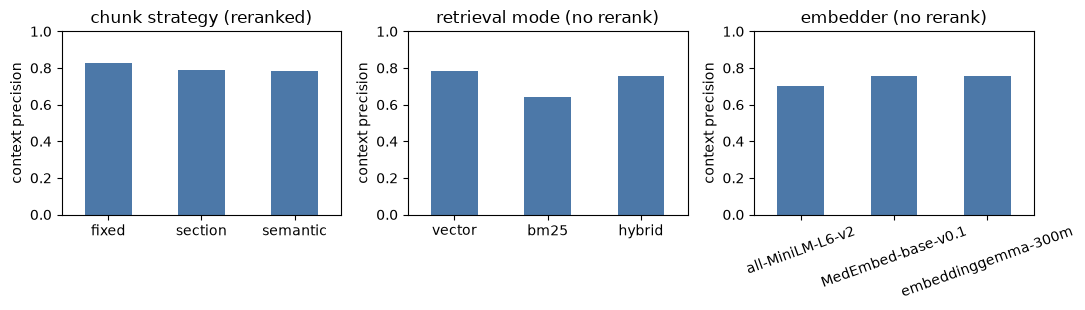

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

# chunk strategy, at the deployed reranker
strat = a[(a["embed_model"] == "MedEmbed-base-v0.1") & (a["mode"] == "hybrid")
          & (a["rerank"] == "gte-reranker-modernbert-base")]
strat.groupby("chunk_strategy")["context_precision"].mean().reindex(
    ["fixed", "section", "semantic"]).plot.bar(
    ax=axes[0], color="#4C78A8", rot=0, title="chunk strategy (reranked)")

# retrieval mode, raw first-stage retrieval so the mode effect is not masked by the reranker
mode = a[(a["chunk_strategy"] == "fixed") & (a["embed_model"] == "MedEmbed-base-v0.1")
         & (a["rerank"] == "none")]
mode.groupby("mode")["context_precision"].mean().reindex(
    ["vector", "bm25", "hybrid"]).plot.bar(
    ax=axes[1], color="#4C78A8", rot=0, title="retrieval mode (no rerank)")

# embedding model, raw first-stage retrieval for the same reason
emb = a[(a["chunk_strategy"] == "fixed") & (a["mode"] == "hybrid") & (a["rerank"] == "none")]
emb.groupby("embed_model")["context_precision"].mean().reindex(
    ["all-MiniLM-L6-v2", "MedEmbed-base-v0.1", "embeddinggemma-300m"]).plot.bar(
    ax=axes[2], color="#4C78A8", rot=20, title="embedder (no rerank)")

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("context precision")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### The selected configuration

The strongest configuration overall is the baseline itself, namely fixed chunks embedded with the
biomedical MedEmbed model, retrieved in hybrid mode and reranked with gte-modernbert, which reaches a
context precision of 0.83 and is the highest of every configuration measured. This is the
configuration carried into the second phase and into the deployed system. Its margin over the nearest
alternatives is small, so the honest reading is that the gte reranker is what secures the result
while the other three choices each add a little on top of an already strong reranked baseline.

## Phase B, basic against agentic answering

With the retrieval fixed, the second sweep compared two ways of answering. The **basic** pipeline
retrieves once and then generates. The **agentic** pipeline is a LangGraph agent that decides for
itself when to search, may reformulate the question and search again, and then answers. Both were
run on the selected strong configuration and, to test a hypothesis, on a deliberately weak one.

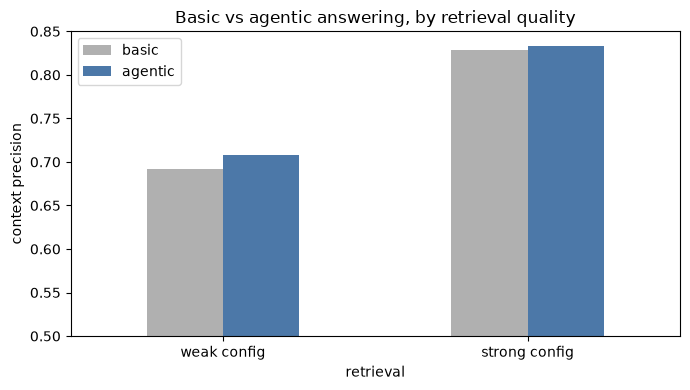

pipeline,basic,agentic
retrieval,,
weak config,0.692,0.708
strong config,0.828,0.833


In [5]:
b = pd.read_csv(RESULTS / "rag_eval_phaseb.csv")
b["retrieval"] = b["rerank"].apply(lambda x: "strong config" if x != "none" else "weak config")
piv = b.pivot_table(index="retrieval", columns="pipeline", values="context_precision")
piv = piv.reindex(["weak config", "strong config"])[["basic", "agentic"]]
piv.plot.bar(figsize=(7, 4), color=["#B0B0B0", "#4C78A8"], rot=0)
plt.ylabel("context precision")
plt.title("Basic vs agentic answering, by retrieval quality")
plt.ylim(0.5, 0.85)
plt.legend(title="")
plt.tight_layout()
plt.show()
piv.round(3)

The gain from the agent is small on both configurations and it comes at a cost. On the strong
retrieval the agent moves context precision from 0.83 to 0.83, a difference too small to matter,
while its faithfulness falls slightly and each answer takes longer because of the extra searches. On
the weak retrieval the agent helps a little more, from 0.69 to 0.71, since its ability to reformulate
and search again recovers some of what the poor first retrieval missed.

The pattern is that the agent is worth relatively more when the retrieval is weak, but even there the
gain is modest, and it never offsets the added latency and the small loss of faithfulness once the
retrieval already works well. The practical conclusion is to invest in retrieval first and to treat
the agent as a limited remedy for weak retrieval rather than an improvement over strong retrieval.
Since the selected configuration retrieves well, the deployed answerer uses the basic pipeline.

## How the evaluation is implemented

The machinery behind the two sweeps lives in `ocular/rag/questions.py`, `ocular/rag/eval_rag.py` and
`ocular/rag/pipeline.py`. This section describes what each part does behind the scenes rather than
reproducing the code.

**Generating the question set.** The function `generate_questions` first keeps only the chunks that
carry at least forty words and do not sit in a methods or materials section, since those passages
rarely hold a clinical question. It shuffles that pool with a fixed seed so the set is reproducible,
then walks it and accepts at most one passage per article. For each candidate the helper
`_generate_one` asks the language model both to decide whether the passage is clinically substantive
and, when it is, to write a paraphrased question together with the answer the passage supports. An
off-topic passage is skipped and the next one is tried, so the fifty saved `Question` records each
carry their source article and section as provenance. `save_questions` writes the set and
`load_questions` reads it back, which is what the cell near the top of this notebook does.

**Scoring one answer.** The function `judge` in `eval_rag.py` scores a single answer with one call to
the language model at temperature zero, so the scores are stable. It passes the question, the
retrieved passages and the answer to the judge and receives a structured `Judgement` that holds the
three metrics and a short rationale, which removes any need to parse free text.

**Running one configuration.** The function `evaluate` ties the two together. For every question it
lets the system produce an answer, has `judge` score that answer, and averages the per-question
metrics and the latency into the single row that a configuration contributes to the results file. The
answering function is a parameter, which is what lets the same evaluator score both the basic and the
agentic pipeline in Phase B.

**The two answering pipelines.** Both live in `pipeline.py` and return the same `RAGResult`, an answer
together with the passages it was built from. `basic_answer` retrieves once and then generates through
`generate.answer`, which instructs the model to answer only from the retrieved passages and to cite
them. `agentic_answer` is a LangGraph agent that decides for itself when to search, may reformulate
the question and search again, and then writes the answer.

## What was run

The question set was generated once with

    python scripts/build_questions.py --n 50

The retrieval sweep was designed as a controlled comparison. Starting from the baseline of fixed
chunks, the MedEmbed embedder, hybrid retrieval and the gte reranker, one axis was varied at a time,

    # reranker axis: none, gte, then ms-marco
    python experiments/run_rag_eval.py --strategies fixed --embedders MedEmbed-base-v0.1 --modes hybrid --rerank both
    python experiments/run_rag_eval.py --strategies fixed --embedders MedEmbed-base-v0.1 --modes hybrid --rerank on --reranker cross-encoder/ms-marco-MiniLM-L-6-v2
    # chunk strategy axis
    python experiments/run_rag_eval.py --strategies section semantic --embedders MedEmbed-base-v0.1 --modes hybrid --rerank on
    # retrieval mode axis, raw retrieval
    python experiments/run_rag_eval.py --strategies fixed --embedders MedEmbed-base-v0.1 --modes vector bm25 --rerank off
    # embedding model axis, raw retrieval
    python experiments/run_rag_eval.py --strategies fixed --embedders all-MiniLM-L6-v2 embeddinggemma-300m --modes hybrid --rerank off
    # mode axis, this time with the reranker, to confirm the deployed choice
    python experiments/run_rag_eval.py --strategies fixed --embedders MedEmbed-base-v0.1 --modes vector --rerank on

and the two answering pipelines were compared on the strong and a weak configuration with

    python experiments/run_phaseb.py
    python experiments/run_phaseb.py --index fixed__all-MiniLM-L6-v2 --mode vector --rerank off

Every run appends to its results CSV and skips configurations already recorded, so the sweep could be
built up one axis at a time rather than in one long execution.

The Phase A commands wrote `experiments/results/rag_eval.csv` and the Phase B commands wrote
`experiments/results/rag_eval_phaseb.csv`. These are the two files that every table and figure above
reads, so the numbers shown are exactly what these commands produced.

## Summary

- The system was evaluated **without a gold set**, using a language model to score faithfulness,
  answer relevance and context precision.
- Faithfulness and answer relevance are saturated across every configuration, so **context
  precision** carried the signal.
- The **reranker** was by far the most influential choice. The gte-modernbert reranker added about
  seven points of context precision, while the lighter ms-marco reranker did not help at all.
- The other choices moved the score much less. Fixed chunks were best, the dense embedders MedEmbed
  and EmbeddingGemma were tied ahead of MiniLM, and the retrieval mode depended on the reranker, with
  hybrid pairing best with it.
- The selected configuration is **fixed chunks, hybrid retrieval, the gte-modernbert reranker and
  the biomedical embedder**, at a context precision of 0.83.
- **Basic answering was chosen** over the agent, whose gain was negligible and came with added
  latency and a small loss of faithfulness.

The retrieval and answering system is now fixed. The remaining work is the application that puts it
in front of a clinician alongside the image classifier.